# Documentação do Programa de Análise de Regressão
### Introdução
#### Este programa foi desenvolvido para facilitar a análise de regressão de dados de entrada em formato CSV. Ele permite carregar dados de um arquivo CSV, calcular a linha de regressão e plotar um gráfico para visualizar os dados originais juntamente com a linha de regressão.

-------MAIN MENU---------
Select an option:
1 --- Load Data
2 --- Show Polynomial Regression
0 --- Exit
Data loaded successfully.
The Pearson correlation coefficient is: 0.946
-------MAIN MENU---------
Select an option:
1 --- Load Data
2 --- Show Polynomial Regression
0 --- Exit
#################################################################
The regression line is y = -438.092 + 0.463x


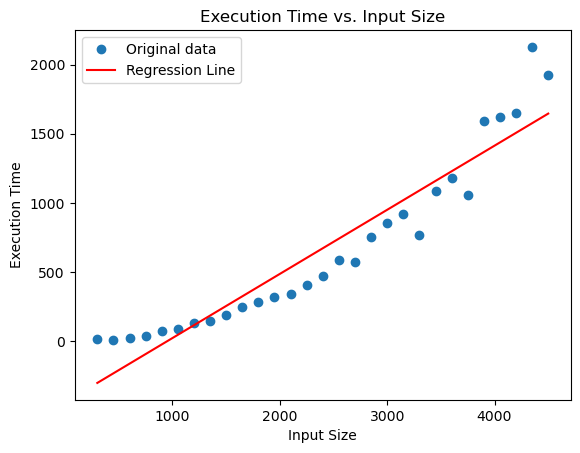

-------MAIN MENU---------
Select an option:
1 --- Load Data
2 --- Show Polynomial Regression
0 --- Exit
Exiting...


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Variáveis globais para armazenar os tempos de execução e os tamanhos de entrada
execution_times = []
input_sizes = []

# Nome do arquivo padrão
default_filename = "execution_times.csv"

def read_from_file():
    """
    Função para ler os dados de um arquivo CSV.

    Usa o nome do arquivo definido na variável global default_filename.
    Os dados são lidos do arquivo usando o Pandas e armazenados nas variáveis globais execution_times e input_sizes.
    """
    global execution_times, input_sizes
    filename = default_filename
    try:
        # Leitura dos dados do arquivo CSV usando o Pandas
        data = pd.read_csv(filename, delimiter=";")
        # Conversão dos dados para o tipo float e armazenamento nas variáveis globais
        input_sizes = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).tolist()
        execution_times = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).tolist()
        print("Data loaded successfully.")
        
        # Calcula o coeficiente de correlação de Pearson
        calculate_pearson_correlation()
        
    except FileNotFoundError:
        print("File not found. Please check the filename and try again.")
    except Exception as e:
        print(f"An error occurred: {e}")

def calculate_pearson_correlation():
    """
    Função para calcular o coeficiente de correlação de Pearson.
    """
    correlation, _ = stats.pearsonr(input_sizes, execution_times)
    print(f"The Pearson correlation coefficient is: {correlation:.3f}")

def calculate_regression_line():
    """
    Função para calcular a linha de regressão.

    Calcula a linha de regressão dos dados de entrada usando a função linregress do módulo stats do Scipy.
    """
    global model
    # Calcula a linha de regressão usando os dados de entrada e de execução
    model = stats.linregress(input_sizes, execution_times)
    plot_graph()

def plot_graph():
    """
    Função para criar o gráfico dos dados e da linha de regressão.

    Cria um gráfico dos dados originais (tamanhos de entrada e tempos de execução) e da linha de regressão calculada.
    """
    print('#################################################################')
    # Imprime a equação da linha de regressão
    print(f'The regression line is y = {model.intercept:.3f} + {model.slope:.3f}x')
    # Plota o gráfico dos dados originais como pontos
    plt.plot(input_sizes, execution_times, 'o', label='Original data')
    # Plota a linha de regressão
    plt.plot(input_sizes, model.intercept + model.slope * pd.Series(input_sizes), 'r', label='Regression Line')
    # Adiciona legendas aos eixos e ao gráfico
    plt.legend()
    plt.xlabel('Input Size')
    plt.ylabel('Execution Time')
    plt.title('Execution Time vs. Input Size')
    # Exibe o gráfico
    plt.show()

# Loop principal do programa
option = -1
while option != 0:
    print("-------MAIN MENU---------")
    print("Select an option:")
    print("1 --- Load Data")
    print("2 --- Show Polynomial Regression")
    print("0 --- Exit")
    try:
        option = int(input("opt: "))
        if option == 1:
            read_from_file()
        elif option == 2:
            if input_sizes and execution_times:
                calculate_regression_line()  # Chama a função para calcular a linha de regressão
            else:
                print("Please load data first by selecting option 1.")
        elif option == 0:
            print("Exiting...")
        else:
            print("Invalid option. Please select a valid option.")
    except ValueError:
        print("Invalid input. Please enter a number.")


# Explicação teórica da Regressão Linear Simples

A regressão linear simples é um modelo utilizado para compreender como uma variável dependente (representada por y) 
se comporta em relação a uma variáveis independente (representada por x)

O principal objetivo é entender como as mudanças em x afetam y, encontrando a linha que melhor se ajusta aos dados. 
Desse modo, é possível fazermos previsões relativamente aos futuros valores de y com base em x.

A fórmula da regressão linear simples é: y = β0 + β1x, sendo:
y: Variável dependente
x: Variável independente
β0: Coeficiente linear, representa o valor esperado de y quando x=0
β0: Coeficiente angular (ou inclinação), indica a mudança esperada em y consoante o valor de x.

Além de estimar os coeficientes da linha de regressão, é importante verificar se o modelo se ajusta bem aos dados, de modo a ser possível de forma clara analisar os dados e tirar uma conclusão com base na sua observação.

No modelo de regressão linear simples, a relação entre a variável dependente (y) e a variável independente (x) é probabilística. 

A média ou valor esperado de E(Y∣x) é uma linha reta dada pela equação: E(Y|X) = β0+ β1(x)

A componente determinística ou de regressão  (β0+ β1x) representa a média esperada de Y para um dado X, enquanto que a componente aleatória ou erro (ε) representa a variação em torno dessa média.

# Explicação teórica do coeficiente de correlação de Pearson

O coeficiente de correlação de Pearson (r) é uma medida estatística que quantifica a força e a direção da relação linear entre duas variáveis. Varia de -1 a 1 e é amplamente utilizado para avaliar a associação entre variáveis quantitativas.

Interpretação do Coeficiente de Correlação (r):

Valores próximos de 1 indicam uma correlação positiva forte, o que significa que as variáveis tendem a aumentar juntas.

Valores próximos de -1 indicam uma correlação negativa forte, onde uma variável tende a diminuir enquanto a outra aumenta.

Um valor de 0 indica ausência de correlação linear entre as variáveis.

Se r>0: indica uma associação linear positiva entre as variáveis. Isso significa que, conforme os valores de uma variável aumentam, os valores da outra variável também tendem a aumentar.

Se r<0:  indica uma associação linear negativa entre as variáveis. Nesse caso, conforme os valores de uma variável aumentam, os valores da outra variável tendem a diminuir.

Quando ∣r∣=1: há uma correlação linear perfeita entre as variáveis, e o sinal de r indica a direção da relação.

Neste caso, o coeficiente de correlação é próximo de 1, o que indica uma correlação positiva forte entre o tamanho da entrada e o tempo de execução.

Interpretação do Coeficiente de Correlação (r):

Como o valor de r é próximo de 1, temos uma associação linear positiva forte entre o tamanho da entrada e o tempo de execução.

Isso significa que, à medida que o tamanho da entrada aumenta, há uma tendência forte para que o tempo de execução também aumente.